<!-- civilpy-title-block -->
<div style="border-top:6px solid #0E3F75; border-bottom:2px solid #C12637; padding:0.6em 0 0.6em 0; margin-bottom:1.2em;">
<span style="font-size:1.5em; font-weight:bold; color:#0E3F75;">Bolted Field Splice Design Process</span><br>
<span style="color:#54585A;">Ohio Department of Transportation &middot; CivilPy Notebook Series</span>
</div>

# Bolted Field Splice — a design-process walkthrough

A bolted field splice is one of the **most expensive square feet of steel on a
bridge**: every bolt is drilled, shipped, and turned by hand in the field. Yet
the bolt count you end up with is decided long before you open the splice
spreadsheet — by how the girder is *framed*, where the *field pieces* break, and
where the splice lands in the *moment envelope*.

This notebook is not a how-to for the splice equations (the AASHTO articles and
the `civilpy` designer's own docstrings cover that). It is a **demonstration of
the design process** that arrives at a cheap splice, in the order a steel-bridge
designer actually works:

1. **The cost of a splice** — what a bolt is worth.
2. **How many splices** — set by girder shipping length, not by choice.
3. **Where to splice** — the analysis (MDX / FEA) moment envelope.
4. **Beam sizing & shop welds** — thickness transitions are shop work, not field
   splices.
5. **Designing the splice** — `civilpy` sizes the plates and bolts and checks
   every AASHTO limit state.
6. **The bill** — the same girder, well-placed vs. badly-placed.

Everything is computed with `civilpy`. The girder section and the moment/shear
**demands are representative of an analysis (MDX) run** — approximating deck
load distribution precisely is the analysis model's job, not this notebook's.
AASHTO LRFD articles are cited throughout. **Units: kip, inch, ksi**; moments in
kip-ft.


In [2]:
%matplotlib inline
import math

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import sympy as sp

from civilpy.structural.aashto.lrfd import (
    design_splice, SpliceInput, Flange, GirderSide, SpliceLoads, BoltSpec,
    PlatePair, WebPlate,
    size_flange_splice_plates, size_web_splice_plate, proportion_limits,
)
from civilpy.structural.beam_bending import Beam, PointLoadV, DistributedLoadV

plt.rcParams["figure.dpi"] = 110

## 1  The cost of a splice

Two rules of thumb the fabrication industry uses to price a bolted splice:

* **Fabrication** — roughly **\$20 per installed high-strength bolt** (drilling,
  faying-surface prep, hardware).
* **Erection** — roughly **10 field-minutes per bolt** (staging, turning to the
  turn-of-nut / tension-control spec, inspection).

A splice has **two sides** (one bolt group each side of the cut), so its cost
scales with twice the per-side bolt count. Keep those two numbers in mind — every
later decision moves them.

In [2]:
FAB_PER_BOLT = 20.0        # $/bolt
ERECT_MIN_PER_BOLT = 10.0  # field-minutes/bolt


def splice_cost(bolts_per_side, n_sides=2):
    bolts = bolts_per_side * n_sides
    return {"bolts": bolts,
            "fab_$": bolts * FAB_PER_BOLT,
            "erect_hr": bolts * ERECT_MIN_PER_BOLT / 60.0}


# The simplified 8th-Edition web method (6.13.6.1.3c) exists because legacy
# methods drove the web bolt count up. A worked contrast:
legacy = splice_cost(342)   # ~600 web + 84 flange bolts, both sides -> per side
modern = splice_cost(62)    # the splice we design below
pd.DataFrame(
    {"per-side bolts": [342, 62], **{k: [legacy[k], modern[k]] for k in
     ("bolts", "fab_$", "erect_hr")}},
    index=["legacy over-bolted splice", "modern simplified method"],
).round(1)

,per-side bolts,bolts,fab_$,erect_hr
legacy over-bolted splice,342,684,13680.0,114.0
modern simplified method,62,124,2480.0,20.7


The two designs carry the *same* girder. The difference is entirely method
and layout — and it is a five-figure swing **per splice**. That is the leverage
this process is chasing.

## 2  How many splices — shipping length decides

Field splices are not a design *preference*; they exist because a girder can only
be **shipped and handled in finite lengths** — about **100 ft** for a typical
haul + crane pick. So the number of field pieces is essentially fixed by the
bridge length:

$$n_\text{sections} = \left\lceil \frac{L}{L_\text{ship}} \right\rceil,
\qquad n_\text{splices} = n_\text{sections} - 1.$$

Anything beyond that minimum is money spent for no structural reason — extra
pieces to fabricate, ship, and crane, **plus** extra field splices to bolt.

In [3]:
def field_sections(length_ft, max_ship_ft=100.0):
    n = max(1, math.ceil(length_ft / max_ship_ft))
    return {"length_ft": length_ft, "sections": n, "splices": n - 1,
            "section_ft": round(length_ft / n, 1)}


bridges = pd.DataFrame([
    field_sections(455),   # long multi-span: several pieces are unavoidable
    field_sections(200),   # short bridge: one splice is plenty
]).set_index("length_ft")
bridges

,sections,splices,section_ft
length_ft,,,
455,5,4,91.0
200,2,1,100.0


A **455-ft** structure genuinely needs ~5 pieces (91-ft sections, 4
splices) — reasonable. A **200-ft** structure needs just **2 pieces and one
splice** (100-ft sections).

Now suppose that 200-ft bridge were instead detailed as **7 field pieces — six
splices** — as real short bridges sometimes are. Shipping forced *one*; the other
**five are avoidable**. At ~124 bolts per splice that is:

In [4]:
avoidable = 5
per_splice = splice_cost(62)          # ~124 bolts/splice
waste = {"extra splices": avoidable,
         "extra bolts": avoidable * per_splice["bolts"],
         "extra fab_$": avoidable * per_splice["fab_$"],
         "extra erect_hr": round(avoidable * per_splice["erect_hr"], 1),
         "extra field pieces to fab/ship/erect": avoidable}
pd.Series(waste)

extra splices                               5.0
extra bolts                               620.0
extra fab_$                             12400.0
extra erect_hr                            103.3
extra field pieces to fab/ship/erect        5.0
dtype: float64

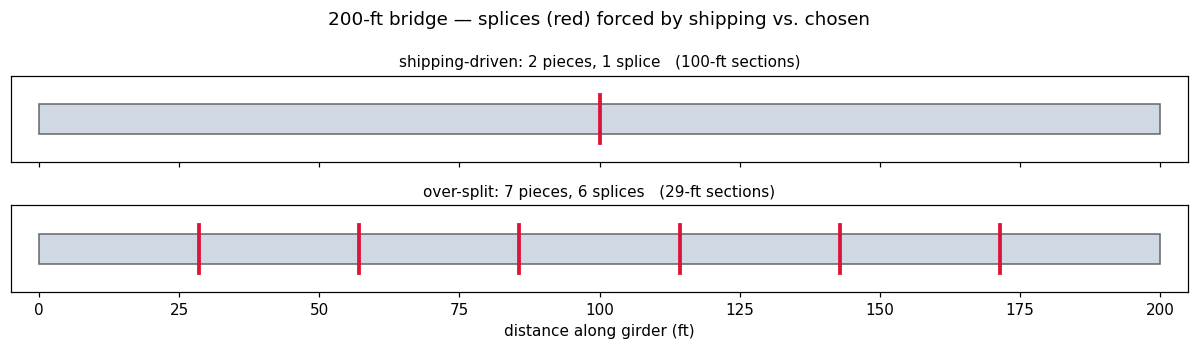

In [5]:
# Elevation: the same 200-ft girder line, shipped as 2 pieces vs. 7.
fig, axes = plt.subplots(2, 1, figsize=(11, 3.2), sharex=True)
for ax, n, label in [(axes[0], 2, "shipping-driven: 2 pieces, 1 splice"),
                     (axes[1], 7, "over-split: 7 pieces, 6 splices")]:
    L = 200.0
    ax.add_patch(mpatches.Rectangle((0, -0.35), L, 0.7, fc="#cfd8e3",
                                    ec="0.4"))
    for k in range(1, n):
        x = L * k / n
        ax.plot([x, x], [-0.55, 0.55], color="crimson", lw=2.5)
    ax.set_xlim(-5, L + 5)
    ax.set_ylim(-1, 1)
    ax.set_yticks([])
    ax.set_title(f"{label}   ({round(L/n,0):.0f}-ft sections)", fontsize=10)
axes[1].set_xlabel("distance along girder (ft)")
fig.suptitle("200-ft bridge — splices (red) forced by shipping vs. chosen")
fig.tight_layout()
plt.show()

## 3  Where to splice — read the moment envelope

Given *how many* splices, the next question is *where along each piece*. The
answer comes from the **analysis model** (MDX for a line girder, or an FEA model
through the MIDAS tie-in): put the splice where the **factored moment is low**,
typically near a **dead-load point of contraflexure**. A low-moment splice
develops less flange force, needs no web moment-couple, and stays small.

`civilpy` carries a light **determinate line-girder analyzer** for quick studies.
Here it builds the shear/moment envelope of one 91-ft field-section span under a
uniform dead load plus a moving axle group — enough to *see* where the demand is
low. (For continuous spans and real deck-load distribution, that is MDX's job.)

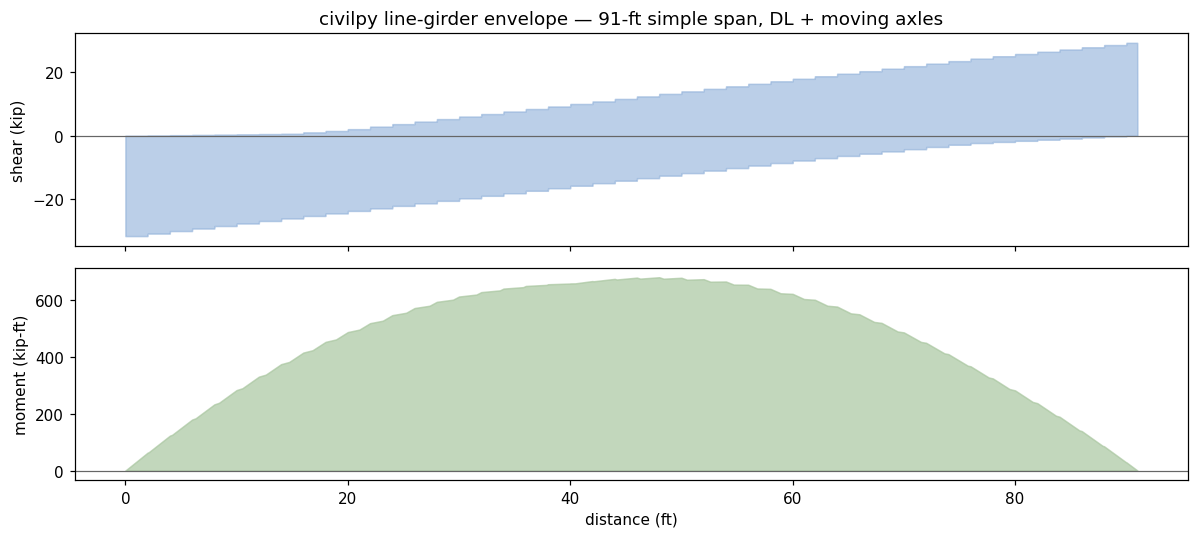

In [6]:
span = 91.0
g = Beam(span)
g.pinned_support = 0.0
g.rolling_support = span
g.add_loads([DistributedLoadV(sp.sympify(-1.2), (0, span))])   # 1.2 kip/ft DL
axles = [PointLoadV(-16, 0), PointLoadV(-16, 14), PointLoadV(-4, 28)]
xv, maxV, minV, maxM, minM = g.get_envelope(axles, step_size=2.0)

fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
a1.fill_between(xv, maxV, minV, color="#8fb0d9", alpha=.6)
a1.axhline(0, color="0.4", lw=.8); a1.set_ylabel("shear (kip)")
a1.set_title("civilpy line-girder envelope — 91-ft simple span, DL + moving axles")
# plotted BMD uses sagging-negative; flip so sagging reads positive
a2.fill_between(xv, -minM, -maxM, color="#a9c6a0", alpha=.7)
a2.axhline(0, color="0.4", lw=.8)
a2.set_ylabel("moment (kip-ft)"); a2.set_xlabel("distance (ft)")
plt.tight_layout(); plt.show()

On a **continuous** girder the picture that matters looks like the sketch
below — a representative MDX moment envelope for a two-span unit. The splice is
placed in the **shaded low-moment window** near the dead-load inflection point,
*not* at the pier where the negative moment peaks.

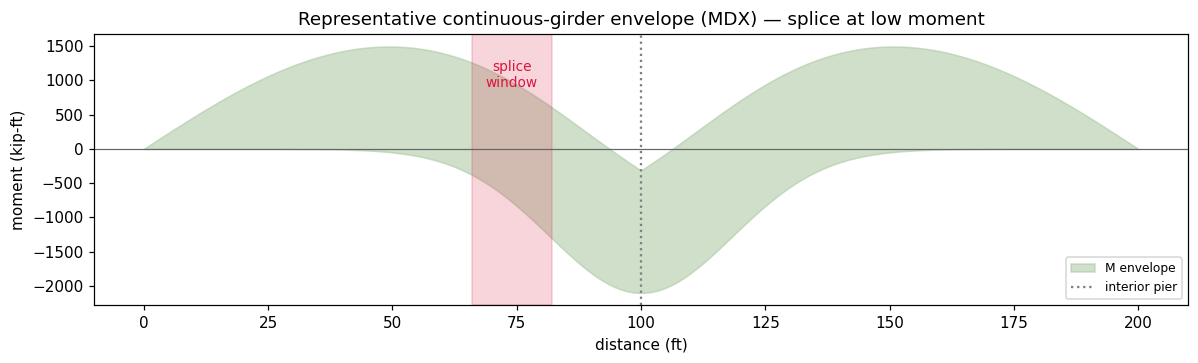

In [7]:
x = np.linspace(0, 200, 401)
# representative two-span envelope (kip-ft): +sag midspan, -hog over pier
pos = 1500 * np.sin(np.pi * x / 100) * (x < 100) + \
      1500 * np.sin(np.pi * (x - 100) / 100) * (x >= 100)
hog = -2100 * np.exp(-((x - 100) / 26) ** 2)
env_hi = np.maximum(pos, 0) + 0.15 * hog
env_lo = np.minimum(pos * 0.15, 0) + hog

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.fill_between(x, env_hi, env_lo, color="#a9c6a0", alpha=.55, label="M envelope")
ax.axhline(0, color="0.4", lw=.8)
ax.axvline(100, color="0.5", ls=":", label="interior pier")
# low-moment splice window around the contraflexure point
ax.axvspan(66, 82, color="crimson", alpha=.18)
ax.text(74, 900, "splice\nwindow", ha="center", color="crimson", fontsize=9)
ax.set_xlabel("distance (ft)"); ax.set_ylabel("moment (kip-ft)")
ax.set_title("Representative continuous-girder envelope (MDX) — splice at low moment")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

At the chosen low-moment location the MDX run reports these unfactored
splice-point demands — **the numbers we design to**:

In [8]:
demands = pd.DataFrame({
    "moment (kip-ft)": [248, 50, 52, 2469, -1754, 1300],
    "shear (kip)":     [-82, -12, -11, 19, -112, -82],
}, index=["DC1 (noncomp DL)", "DC2 (comp DL)", "DW (wearing surf)",
          "LL+ (+I)", "LL- (+I)", "deck casting"])
demands

,moment (kip-ft),shear (kip)
DC1 (noncomp DL),248,-82
DC2 (comp DL),50,-12
DW (wearing surf),52,-11
LL+ (+I),2469,19
LL- (+I),-1754,-112
deck casting,1300,-82


## 4  Beam sizing & shop welds — what the splice is *not* for

The girder section changes along its length: flanges thicken toward the piers
where moment is high and thin out toward midspan. **Those thickness transitions
are made in the shop**, with automated full-penetration butt welds — cheap, and
invisible to the erector. A **field splice is not a section-transition device**;
it exists only because the piece has to ship.

So a good splice usually joins two *well-proportioned* girder sections that
happen to fall at the shipping break. Here are the two sections meeting at our
splice — different flange sizes and steel grades, both checked against the
AASHTO 6.10.2 web/flange proportion limits.

In [9]:
def section_row(name, side):
    r = proportion_limits(
        d_web=side.web_depth, t_w=side.web_thickness,
        b_fc=side.top_flange.width, t_fc=side.top_flange.thickness,
        b_ft=side.bottom_flange.width, t_ft=side.bottom_flange.thickness)
    return {"section": name,
            "top flange": f"{side.top_flange.thickness}x{side.top_flange.width} "
                          f"{side.top_flange.material}",
            "bot flange": f"{side.bottom_flange.thickness}x"
                          f"{side.bottom_flange.width} {side.bottom_flange.material}",
            "web": f"{side.web_thickness}x{side.web_depth}",
            "6.10.2 proportions": "OK" if r.ok else "NG"}


left = GirderSide(Flange("Grade 50W", 1.0, 16.0),
                  Flange("Grade 50W", 1.375, 18.0),
                  "Grade 50W", 0.5, 69.0, haunch=1.0,
                  stiffener_spacing_ft=17.25, stiffened=True)
right = GirderSide(Flange("HPS Grade 70W", 1.0, 18.0),
                   Flange("HPS Grade 70W", 1.0, 20.0),
                   "Grade 50W", 0.5625, 69.0, haunch=1.0,
                   stiffener_spacing_ft=12.0, stiffened=True)
pd.DataFrame([section_row("left (approach)", left),
              section_row("right (toward pier)", right)]).set_index("section")

,top flange,bot flange,web,6.10.2 proportions
section,,,,
left (approach),1.0x16.0 Grade 50W,1.375x18.0 Grade 50W,0.5x69.0,OK
right (toward pier),1.0x18.0 HPS Grade 70W,1.0x20.0 HPS Grade 70W,0.5625x69.0,OK


## 5  Designing the splice with civilpy

Now the splice itself. First `civilpy` **sizes the splice plates from the girder
geometry** (C6.13.6.1.3b; the outer plate spans the narrower flange, the inner
pair clears the web and its welds, thicknesses are proportioned within the 10%
double-shear band). The web plate thickness and the sealing bolt pitch come from
6.13.6.1.3c / 6.13.2.6.2.

In [10]:
top_p = size_flange_splice_plates(
    flange_width_left=16.0, flange_width_right=18.0, flange_thickness=1.0,
    web_thickness_left=0.5, web_thickness_right=0.5625,
    weld_size=0.3125, outer_thickness=0.625)
bot_p = size_flange_splice_plates(
    flange_width_left=18.0, flange_width_right=20.0, flange_thickness=1.375,
    web_thickness_left=0.5, web_thickness_right=0.5625,
    weld_size=0.3125, outer_thickness=0.75)
web_p = size_web_splice_plate(
    web_depth=69.0, web_thickness=0.5, web_thickness_other=0.5625,
    flange_clearance=3.0)

pd.DataFrame([
    {"plate": "top flange", "outer": f"{top_p.outer_thickness}x{top_p.outer_width}",
     "inner (x2)": f"{top_p.inner_thickness}x{top_p.inner_width}",
     "note": f"web gap {top_p.clearance}\""},
    {"plate": "bottom flange", "outer": f"{bot_p.outer_thickness}x{bot_p.outer_width}",
     "inner (x2)": f"{bot_p.inner_thickness}x{bot_p.inner_width}",
     "note": f"web gap {bot_p.clearance}\""},
    {"plate": "web (x2)", "outer": f"{web_p.thickness}x{web_p.height}",
     "inner (x2)": "-",
     "note": f"seal pitch {web_p.max_pitch_seal}\", {web_p.min_bolts_per_row}/row"},
]).set_index("plate")

,outer,inner (x2),note
plate,,,
top flange,0.625x16.0,0.6875x7.0,"web gap 1.4375"""
bottom flange,0.75x18.0,0.875x8.0,"web gap 1.4375"""
web (x2),0.3125x63.0,-,"seal pitch 5.25"", 13/row"


Feed the sized plates and the MDX demands into `design_splice`, which
sizes the bolt groups, lays them out, and runs every limit state.

In [11]:
def build_input(loads):
    return SpliceInput(
        left=left, right=right, loads=loads,
        bolts=BoltSpec("A325", 0.875, True, False, "B", "standard"),
        top_plates=PlatePair("Grade 50W", top_p.inner_thickness, top_p.inner_width,
                             top_p.outer_thickness, top_p.outer_width, 2),
        bottom_plates=PlatePair("Grade 50W", bot_p.inner_thickness, bot_p.inner_width,
                                bot_p.outer_thickness, bot_p.outer_width, 2),
        web_plate=WebPlate("Grade 50W", web_p.thickness, 2),
        deck_composite=True, deck_thickness=9.0, deck_eff_width=144.0, fc=4.0,
        top_flange_rows=4, bottom_flange_rows=4, web_rows=2, bolt_spacing=3.0,
        flange_edge=2.0, flange_end=1.5, web_edge=2.0, web_end=1.5,
        web_weld_size=0.3125, web_weld_clearance=0.375, girder_gap=0.75,
        entering_tightening=3.0, design_year=2020)


well = SpliceLoads(248, -82, 50, -12, 52, -11, 2469, 19, -1754, -112, 1300, -82)
d = design_splice(build_input(well))

print("Factored moments (kip-ft):",
      {k: round(v, 0) for k, v in d.factored_moments.items()})
print("Flange design force Pfy  top %.0f  bottom %.0f kip"
      % (d.top_flange.design_force, d.bottom_flange.design_force))
print("Web horizontal force Hw = %.0f kip  ->  flanges carry the moment, "
      "web is shear + sealing only" % d.web.extra["hw_strength"])
pd.DataFrame([{"component": c.name, "rows": c.bolt_rows,
               "bolts/side": c.total_bolts,
               "plate": f"{c.plate_thickness}x{c.plate_width}x"
                        f"{round(c.plate_length,1)}"}
              for c in d.components]).set_index("component")

Factored moments (kip-ft): {'deck_cast': 1820.0, 'strength_pos': 4771.0, 'strength_neg': -2768.0, 'service_pos': 3560.0, 'service_neg': -1930.0}
Flange design force Pfy  top 722  bottom 1155 kip
Web horizontal force Hw = 0 kip  ->  flanges carry the moment, web is shear + sealing only


,rows,bolts/side,plate
component,,,
top_flange,4,12,0.625x16.0x18.8
bottom_flange,4,24,0.75x18.0x36.8
web,2,26,0.3125x14.75x63.0


In [12]:
def checks_table(component):
    return pd.DataFrame([{
        "article": chk.article, "check": chk.name,
        "phi*cap": round(chk.factored_capacity, 1),
        "demand": None if chk.demand is None else round(chk.demand, 1),
        "ratio": None if chk.ratio is None else round(chk.ratio, 3),
        "verdict": "OK" if chk.ok is not False else "NG",
    } for chk in component.checks])


print("Overall design OK:", d.ok)
print("\nTop-flange limit states (block shear governs):")
checks_table(d.top_flange)

Overall design OK: True

Top-flange limit states (block shear governs):


,article,check,phi*cap,demand,ratio,verdict
0,6.13.2.8,top flange Service II slip,468.0,330.0,1.418,OK
1,6.13.5.2,outer plate yield (tension),475.0,361.1,1.316,OK
2,6.13.5.2,Net Section Reduction Limit,8.5,7.7,1.110,OK
3,6.13.6.1.3,outer plate net-section fracture,428.8,361.1,1.188,OK
4,6.13.4,outer plate block shear,460.9,361.1,1.277,OK
5,6.13.5.2,inner plate yield (tension),457.2,361.1,1.266,OK
6,6.13.5.2,Net Section Reduction Limit,8.2,7.0,1.161,OK
7,6.13.6.1.3,inner plate net-section fracture,394.6,361.1,1.093,OK
8,6.13.4,inner plate block shear,507.0,361.1,1.404,OK
9,6.13.4,girder flange block shear (Mode 1),900.9,722.1,1.248,OK


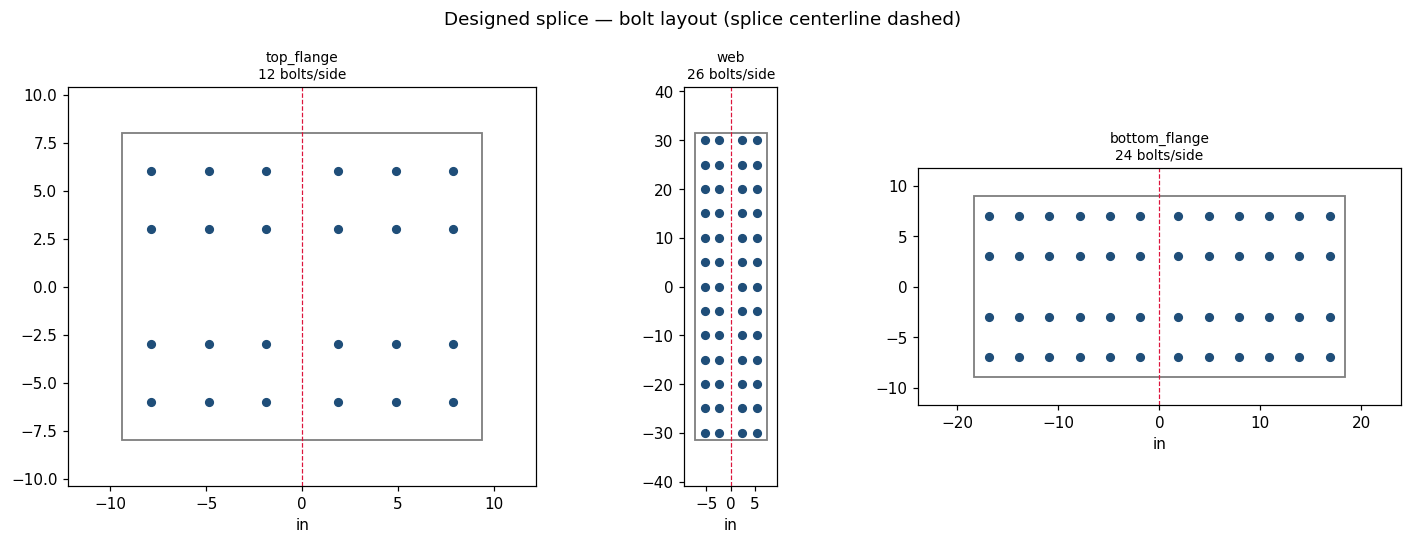

In [13]:
def _flange_xy(c):
    n_per_group = c.bolt_rows // 2
    ys, y = [], c.edge
    for gi in range(2):
        for i in range(n_per_group):
            ys.append(y)
            if i < n_per_group - 1:
                y += c.gage_bolts
        if gi == 0:
            y += c.gage_groups
    ys = [v - c.plate_width / 2 for v in ys]
    cols = c.total_bolts // c.bolt_rows
    xs = []
    for col in range(cols):
        dx = c.pitch_groups / 2 + col * c.pitch
        xs += [dx, -dx]
    return xs, ys


def _web_xy(c):
    per_row = c.total_bolts // c.bolt_rows
    xs = []
    for line in range(c.bolt_rows):
        dx = c.gage_groups / 2 + line * c.gage_bolts
        xs += [dx, -dx]
    ys = [(-(per_row - 1) / 2 + k) * c.pitch for k in range(per_row)]
    return xs, ys


def plot_layout(design, title=""):
    fig, axes = plt.subplots(1, 3, figsize=(13, 5))
    for ax, (c, kind) in zip(axes, [(design.top_flange, "plan"),
                                    (design.web, "elev"),
                                    (design.bottom_flange, "plan")]):
        if kind == "plan":
            xs, ys = _flange_xy(c); L, W = c.plate_length, c.plate_width
        else:
            xs, ys = _web_xy(c); L, W = c.plate_width, c.plate_length
        ax.add_patch(mpatches.Rectangle((-L/2, -W/2), L, W, fill=False,
                                        edgecolor="0.5", linewidth=1.2))
        for xx in xs:
            for yy in ys:
                ax.plot(xx, yy, "o", ms=5, color="#1f4e79")
        ax.axvline(0, ls="--", lw=0.8, color="crimson")
        ax.set_title(f"{c.name}\n{c.total_bolts} bolts/side", fontsize=9)
        ax.set_aspect("equal"); ax.margins(0.15); ax.set_xlabel("in")
    fig.suptitle(title); fig.tight_layout(); plt.show()


plot_layout(d, "Designed splice — bolt layout (splice centerline dashed)")

## 6  The bill — placement is the lever

The payoff of the whole process. Take the **identical girder and the identical
sized plates**, and only move the splice: keep it at the low-moment window (§3),
versus forcing it near the pier where the envelope peaks. The engine re-sizes the
bolts for the higher demand.

In [14]:
def bolts_per_side(des):
    return (des.top_flange.total_bolts + des.web.total_bolts
            + des.bottom_flange.total_bolts)


# near-pier: same girder, ~2.4x the live-load moment of the low-moment window
pier = SpliceLoads(248, -82, 50, -12, 52, -11, int(2469 * 2.4), 19,
                   int(-1754 * 2.4), -112, 1300, -82)
d_pier = design_splice(build_input(pier))

rows = []
for name, des in [("well-placed (low M)", d), ("near-pier (high M)", d_pier)]:
    bps = bolts_per_side(des)
    c = splice_cost(bps)
    rows.append({"placement": name,
                 "|M_strength| (kip-ft)": round(max(
                     abs(des.factored_moments["strength_pos"]),
                     abs(des.factored_moments["strength_neg"])), 0),
                 "Hw (kip)": round(des.web.extra["hw_strength"], 0),
                 "web bolts/side": des.web.total_bolts,
                 "bolts/splice": c["bolts"], "fab_$": c["fab_$"],
                 "erect_hr": round(c["erect_hr"], 1),
                 "all checks OK": des.ok})
pd.DataFrame(rows).set_index("placement")

,|M_strength| (kip-ft),Hw (kip),web bolts/side,bolts/splice,fab_$,erect_hr,all checks OK
placement,,,,,,,
well-placed (low M),4771.0,0.0,26,124,2480.0,20.7,True
near-pier (high M),10819.0,2492.0,50,172,3440.0,28.7,False


Same steel, same plates. Moving the splice into the high-moment region
switches on the 6.13.6.1.3c web moment-couple (`Hw`), **roughly doubles the web
bolts**, drives up fabrication and field-erection cost, **and still fails the
limit-state checks** — it would force heavier flanges and plates too. The cheap
splice was won three sections upstream, by placing the break where the moment is
low.

## 7  Summary — the levers, most powerful first

1. **Ship-length sets the piece count.** `n_splices = ceil(L / L_ship) - 1`.
   Every splice beyond that is pure cost — the 200-ft/6-splice case wastes five
   splices and five field pieces.
2. **Placement sets the demand.** A splice in a low-moment window develops less
   flange force and needs no web moment-couple; the same splice near a pier can
   double the web bolts and fail.
3. **Shop welds absorb section changes.** Flange thickness transitions belong to
   automated shop butt welds, not field bolts.
4. **Then design efficiently.** The simplified 6.13.6.1.3c web method and the
   `civilpy` plate-sizing tools keep the final bolt count — the *smallest* lever —
   small.

The splice-plate spreadsheet is the last step, and the least of them. This
notebook computed the whole chain with `civilpy`
(`size_flange_splice_plates`, `size_web_splice_plate`, `design_splice`, and the
line-girder `Beam`); the girder section and moment/shear demands stand in for an
MDX analysis run.

In [3]:
import rhino3dm
m = rhino3dm.File3dm.Read(r"test_girders.3dm")
for obj in m.Objects:
    a = obj.Attributes
    kind = a.GetUserString("gdr.kind")
    if kind:
        print(kind, a.GetUserString("gdr.line"),
              a.GetUserString("gdr.shape"), a.GetUserString("gdr.fixity"))

girder 1 W24X104 
support 1  expansion
support 1  expansion
support 1  fixed
support 1  expansion
girder 2 W24X104 
support 2  expansion
support 2  expansion
support 2  fixed
support 2  expansion
girder 3 W24X104 
support 3  expansion
support 3  expansion
support 3  fixed
support 3  expansion
girder 4 W24X104 
support 4  expansion
support 4  expansion
support 4  fixed
support 4  expansion
girder 5 W24X104 
support 5  expansion
support 5  expansion
support 5  fixed
support 5  expansion
splice 2  
